In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import fcn_resnet50
import os
import json
import numpy as np
from PIL import Image
import base64
import io
import zlib
from collections import defaultdict
import json
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
class FoodSegDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.img_dir = os.path.join(root_dir, split, 'img')
        self.ann_dir = os.path.join(root_dir, split, 'ann')
        self.images = sorted(os.listdir(self.img_dir))
        self.target_size = (384, 512)

        # Create class ID mapping including background
        self.class_mapping = {'background': 0}  # Background as class 0
        self.reverse_mapping = {0: 'background'}
        self.create_class_mapping()

    def create_class_mapping(self):
        class_ids = set()
        for img_name in self.images:
            ann_name = os.path.splitext(img_name)[0] + '.jpg.json'
            ann_path = os.path.join(self.ann_dir, ann_name)
            with open(ann_path, 'r') as f:
                annotation = json.load(f)
            for obj in annotation['objects']:
                class_ids.add(obj['classId'])
        for idx, class_id in enumerate(sorted(class_ids), start=1):  # Start from 1
            self.class_mapping[class_id] = idx
            self.reverse_mapping[idx] = class_id
        self.num_classes = len(self.class_mapping)  # Now 104 with background
        print(f"Total classes including background: {self.num_classes}")

    def decode_bitmap(self, bitmap_data, origin, size):
        try:
            # Remove whitespace and add padding if necessary
            bitmap_data = bitmap_data.strip()
            padding = len(bitmap_data) % 4
            if padding:
                bitmap_data += '=' * (4 - padding)

            # Decode base64 data
            decoded_data = base64.b64decode(bitmap_data)

            try:
                decoded_data = zlib.decompress(decoded_data)
            except zlib.error:
                pass

            stream = io.BytesIO(decoded_data)
            bitmap_image = Image.open(stream)
            mask = np.array(bitmap_image)

            if len(mask.shape) == 3:
                mask = mask[:, :, 0]

            full_mask = np.zeros((size['height'], size['width']), dtype=np.int32)

            h, w = mask.shape
            x, y = origin
            x_end = min(x + w, size['width'])
            y_end = min(y + h, size['height'])
            w = x_end - x
            h = y_end - y

            full_mask[y:y+h, x:x+w] = mask[:h, :w]

            return full_mask

        except Exception as e:
            print(f"Error decoding bitmap: {str(e)}")
            return np.zeros((size['height'], size['width']), dtype=np.int32)

    def __getitem__(self, idx):
        try:
            # Load image
            img_name = self.images[idx]
            img_path = os.path.join(self.img_dir, img_name)
            image = Image.open(img_path).convert('RGB')

            # Load annotation
            ann_name = os.path.splitext(img_name)[0] + '.jpg.json'
            ann_path = os.path.join(self.ann_dir, ann_name)

            with open(ann_path, 'r') as f:
                annotation = json.load(f)

            # Create segmentation mask initialized with background (0)
            mask = np.zeros((annotation['size']['height'],
                           annotation['size']['width']), dtype=np.int32)

            # Create a combined object mask to track all segmented areas
            combined_object_mask = np.zeros_like(mask, dtype=bool)

            # Fill mask with mapped class labels
            for obj in annotation['objects']:
                original_class_id = obj['classId']
                mapped_class_id = self.class_mapping[original_class_id]
                bitmap_data = obj['bitmap']['data']
                origin = obj['bitmap']['origin']

                obj_mask = self.decode_bitmap(bitmap_data, origin, annotation['size'])
                mask[obj_mask > 0] = mapped_class_id
                combined_object_mask[obj_mask > 0] = True

            # Ensure all non-segmented areas remain as background (class 0)
            mask[~combined_object_mask] = 0

            # Convert mask to PIL Image for resizing
            mask_pil = Image.fromarray(mask.astype(np.uint8))

            # Resize both image and mask to target size
            image = image.resize(self.target_size[::-1], Image.Resampling.BILINEAR)
            mask_pil = mask_pil.resize(self.target_size[::-1], Image.Resampling.NEAREST)

            # Apply transforms to image
            if self.transform:
                image = self.transform(image)

            # Convert mask back to tensor
            mask = torch.from_numpy(np.array(mask_pil)).long()

            return image, mask

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            dummy_image = torch.zeros((3, *self.target_size))
            dummy_mask = torch.zeros(self.target_size, dtype=torch.long)
            return dummy_image, dummy_mask

    def __len__(self):
        return len(self.images)

In [ ]:
def compute_iou(pred_mask, true_mask, num_classes=104, epsilon=1e-6):
    iou_per_class = []
    for class_id in range(num_classes):
        # Create binary masks for each class
        pred_class_mask = (pred_mask == class_id)
        true_class_mask = (true_mask == class_id)

        # Calculate intersection and union
        intersection = torch.logical_and(pred_class_mask, true_class_mask).sum().float()
        union = torch.logical_or(pred_class_mask, true_class_mask).sum().float()

        # Avoid division by zero
        iou = intersection / (union + epsilon) if union > 0 else torch.tensor(0.0)
        iou_per_class.append(iou)

    # Calculate mean IoU, excluding classes with no ground truth
    valid_iou = [iou for iou in iou_per_class if iou > 0]
    return torch.mean(torch.tensor(valid_iou)) if valid_iou else torch.tensor(0.0)

In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Dataset parameters
data_root = '//kaggle/input/foodsegmentation'  # Update this path
batch_size = 8

# Transform for input images
transform = transforms.Compose([
    transforms.Resize((384, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device,num_classes):
    model = model.to(device)
    best_val_loss = float('inf')
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # Validation Phase with IoU Metric
        model.eval()
        val_loss = 0.0
        iou_score = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)['out']
                loss = criterion(outputs, masks)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                iou_score += compute_iou(preds, masks, num_classes)

        avg_val_loss = val_loss / len(val_loader)
        avg_iou = iou_score / len(val_loader)
        print(f"Validation Loss: {avg_val_loss:.4f}, IoU: {avg_iou:.4f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_food_segmentation_model_test.pth')

    print("Training completed!")
    return model
try:
    # Create datasets
    print("Creating datasets...")


    # Create data loaders
    print("Creating data loaders...")
    train_dataset = FoodSegDataset(data_root, 'train', transform=transform)
    val_dataset = FoodSegDataset(data_root, 'test', transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    model = fcn_resnet50(num_classes=104)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 20
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device,num_classes=104)

except Exception as e:
    print(f"An error occurred: {str(e)}")

Using device: cuda
Creating datasets...
Creating data loaders...
Total classes including background: 104
Total classes including background: 104


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s] 


Epoch 1/30, Train Loss: 1.8674
Validation Loss: 1.6592, IoU: 0.2934
Epoch 2/30, Train Loss: 1.5470
Validation Loss: 1.5252, IoU: 0.3159
Epoch 3/30, Train Loss: 1.4063
Validation Loss: 1.4353, IoU: 0.3519
Epoch 4/30, Train Loss: 1.3016
Validation Loss: 1.3233, IoU: 0.3853
Epoch 5/30, Train Loss: 1.2300
Validation Loss: 1.3179, IoU: 0.3834
Epoch 6/30, Train Loss: 1.1604
Validation Loss: 1.1900, IoU: 0.4244
Epoch 7/30, Train Loss: 1.1000
Validation Loss: 1.1967, IoU: 0.4234
Epoch 8/30, Train Loss: 1.0421
Validation Loss: 1.1691, IoU: 0.4239
Epoch 9/30, Train Loss: 0.9839
Validation Loss: 1.2238, IoU: 0.4061
Epoch 10/30, Train Loss: 0.9294
Validation Loss: 1.1988, IoU: 0.4302
Epoch 11/30, Train Loss: 0.8727
Validation Loss: 1.1918, IoU: 0.4265
Epoch 12/30, Train Loss: 0.8195
Validation Loss: 1.1531, IoU: 0.4407
Epoch 13/30, Train Loss: 0.7575
Validation Loss: 1.2426, IoU: 0.4306
Epoch 14/30, Train Loss: 0.7041
Validation Loss: 1.1997, IoU: 0.4397
Epoch 15/30, Train Loss: 0.6586
Validation 

KeyboardInterrupt: 

In [ ]:
def load_image(image_path, target_size=(384, 512)):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(target_size[::-1], Image.Resampling.BILINEAR)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image)
    return image_tensor, image

In [ ]:
def get_prediction(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output = model(image_tensor)['out']
        probabilities = F.softmax(output, dim=1)
        predictions = torch.argmax(probabilities, dim=1)
    return predictions[0].cpu().numpy()

In [ ]:
def get_class_names(dataset):
    class_names = {0: 'background'}  # Explicitly add background class

    for idx, class_id in dataset.reverse_mapping.items():
        if idx == 0:  # Skip background as we've already added it
            continue
        for img_name in dataset.images:
            ann_name = os.path.splitext(img_name)[0] + '.jpg.json'
            ann_path = os.path.join(dataset.ann_dir, ann_name)
            with open(ann_path, 'r') as f:
                annotation = json.load(f)
            for obj in annotation['objects']:
                if obj['classId'] == class_id:
                    class_names[idx] = obj['classTitle']
                    break
            if idx in class_names:
                break
    return class_names

In [ ]:
def create_colored_mask(prediction, dataset, class_names):
    # Create colormap with consistent colors
    colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, dataset.num_classes))
    colors = (colors[:, :3] * 255).astype(np.uint8)

    # Make background color blue
    colors[0] = [0, 0, 255]  # RGB for blue

    colored_mask = colors[prediction]
    return colored_mask, colors

def overlay_mask(image, colored_mask, alpha=0.5):
    image_np = np.array(image).astype(np.uint8)
    colored_mask = colored_mask.astype(np.uint8)
    if image_np.shape != colored_mask.shape:
        colored_mask = cv2.resize(colored_mask, (image_np.shape[1], image_np.shape[0]))
    overlay = cv2.addWeighted(image_np, 1 - alpha, colored_mask, alpha, 0)
    return overlay

In [ ]:
def calculate_pixel_accuracy(prediction, ground_truth):
    # Convert to numpy if tensors
    if torch.is_tensor(prediction):
        prediction = prediction.cpu().numpy()
    if torch.is_tensor(ground_truth):
        ground_truth = ground_truth.cpu().numpy()

    # Ensure the arrays are of the same shape
    assert prediction.shape == ground_truth.shape, "Prediction and ground truth must have the same shape"

    # Calculate pixel-wise accuracy
    correct_pixels = np.sum(prediction == ground_truth)
    total_pixels = prediction.size

    return correct_pixels / total_pixels

def calculate_mean_iou(prediction, ground_truth, num_classes=104, ignore_background=False):
    # Convert to numpy if tensors
    if torch.is_tensor(prediction):
        prediction = prediction.cpu().numpy()
    if torch.is_tensor(ground_truth):
        ground_truth = ground_truth.cpu().numpy()

    # Ensure the arrays are of the same shape
    assert prediction.shape == ground_truth.shape, "Prediction and ground truth must have the same shape"

    # Calculate IoU for each class
    iou_per_class = {}
    for class_id in range(num_classes):
        # Create binary masks for the current class
        pred_class_mask = (prediction == class_id)
        true_class_mask = (ground_truth == class_id)

        # Calculate intersection and union
        intersection = np.logical_and(pred_class_mask, true_class_mask).sum()
        union = np.logical_or(pred_class_mask, true_class_mask).sum()

        # Calculate IoU, avoiding division by zero
        iou = intersection / (union + 1e-6) if union > 0 else 0
        iou_per_class[class_id] = iou

    # Collect non-zero IoU values
    if ignore_background:
        # Exclude background class (usually class 0)
        iou_values = [iou for cls, iou in iou_per_class.items() if cls != 0 and iou > 0]
    else:
        iou_values = [iou for iou in iou_per_class.values() if iou > 0]

    # Calculate mean IoU only for non-zero classes
    mean_iou = np.mean(iou_values) if iou_values else 0

    return mean_iou, iou_per_class

def calculate_dice_coefficient(prediction, ground_truth, num_classes=104, ignore_background=False):
    # Convert to numpy if tensors
    if torch.is_tensor(prediction):
        prediction = prediction.cpu().numpy()
    if torch.is_tensor(ground_truth):
        ground_truth = ground_truth.cpu().numpy()

    # Ensure the arrays are of the same shape
    assert prediction.shape == ground_truth.shape, "Prediction and ground truth must have the same shape"

    # Calculate Dice Coefficient for each class
    dice_per_class = {}
    for class_id in range(num_classes):
        # Create binary masks for the current class
        pred_class_mask = (prediction == class_id)
        true_class_mask = (ground_truth == class_id)

        # Calculate intersection, prediction, and ground truth pixels
        intersection = np.logical_and(pred_class_mask, true_class_mask).sum()
        pred_pixels = pred_class_mask.sum()
        true_pixels = true_class_mask.sum()

        # Calculate Dice Coefficient, avoiding division by zero
        dice = (2 * intersection) / (pred_pixels + true_pixels + 1e-6)
        dice_per_class[class_id] = dice

    # Collect non-zero Dice Coefficient values
    if ignore_background:
        # Exclude background class (usually class 0)
        dice_values = [dice for cls, dice in dice_per_class.items() if cls != 0 and dice > 0]
    else:
        dice_values = [dice for dice in dice_per_class.values() if dice > 0]

    # Calculate mean Dice Coefficient only for non-zero classes
    mean_dice = np.mean(dice_values) if dice_values else 0

    return mean_dice, dice_per_class

In [ ]:
def predict_and_visualize(model, image_path, class_names, dataset, device, ground_truth=None, save_path=None):
    # Existing prediction and visualization code remains the same
    image_tensor, original_image = load_image(image_path)
    prediction = get_prediction(model, image_tensor, device)
    colored_mask, colors = create_colored_mask(prediction, dataset, class_names)
    overlay = overlay_mask(original_image, colored_mask)

    # Metrics calculation
    metrics = {
        'pixel_accuracy': None,
        'mean_iou': None,
        'class_iou': None,
        'mean_dice': None,
        'class_dice': None
    }

    # Calculate metrics if ground truth is provided
    if ground_truth is not None:
        # Resize ground truth to match prediction size if necessary
        if ground_truth.shape != prediction.shape:
            ground_truth = np.array(Image.fromarray(ground_truth).resize(
                (prediction.shape[1], prediction.shape[0]),
                Image.Resampling.NEAREST
            ))

        # Calculate pixel accuracy
        metrics['pixel_accuracy'] = calculate_pixel_accuracy(prediction, ground_truth)

        # Calculate mean IoU
        metrics['mean_iou'], metrics['class_iou'] = calculate_mean_iou(prediction, ground_truth)

        # Calculate Dice Coefficient
        metrics['mean_dice'], metrics['class_dice'] = calculate_dice_coefficient(prediction, ground_truth)

    # Visualization code remains the same as in the original function
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    ax1.imshow(original_image)
    ax1.set_title('Original Image')
    ax1.axis('off')
    ax2.imshow(colored_mask)
    ax2.set_title('Segmentation Mask')
    ax2.axis('off')
    ax3.imshow(overlay)
    ax3.set_title('Overlay')
    ax3.axis('off')

    # Create legend elements
    legend_elements, legend_labels = [], []
    unique_classes = np.unique(prediction)

    # Always include background if it exists in the prediction
    if 0 in unique_classes:  # Background class
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[0]/255))
        legend_labels.append('background')

    # Add other classes
    for class_idx in unique_classes:
        if class_idx != 0 and class_idx in class_names:  # Skip background as it's already added
            legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[class_idx]/255))
            legend_labels.append(class_names[class_idx])

    # Add legend with better positioning and spacing
    fig.legend(legend_elements, legend_labels,
              loc='center left',
              bbox_to_anchor=(1.0, 0.5),
              title='Classes Present',
              borderaxespad=0.5,
              labelspacing=1.2)

    # Add metrics to the plot if calculated
    if metrics['pixel_accuracy'] is not None:
        plt.suptitle(
            f"Pixel Accuracy: {metrics['pixel_accuracy']:.4f}\n"
            f"Mean IoU: {metrics['mean_iou']:.4f}\n"
            f"Mean Dice Coefficient: {metrics['mean_dice']:.4f}",
            fontsize=10
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    return prediction, colored_mask, overlay, metrics, legend_labels

Using device: cuda


/tmp/ipykernel_30/2855913219.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/kaggle/input/modelss/best_food_segmentation_model_test (2).pth',


Total classes including background: 104


/tmp/ipykernel_30/3415556691.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, dataset.num_classes))


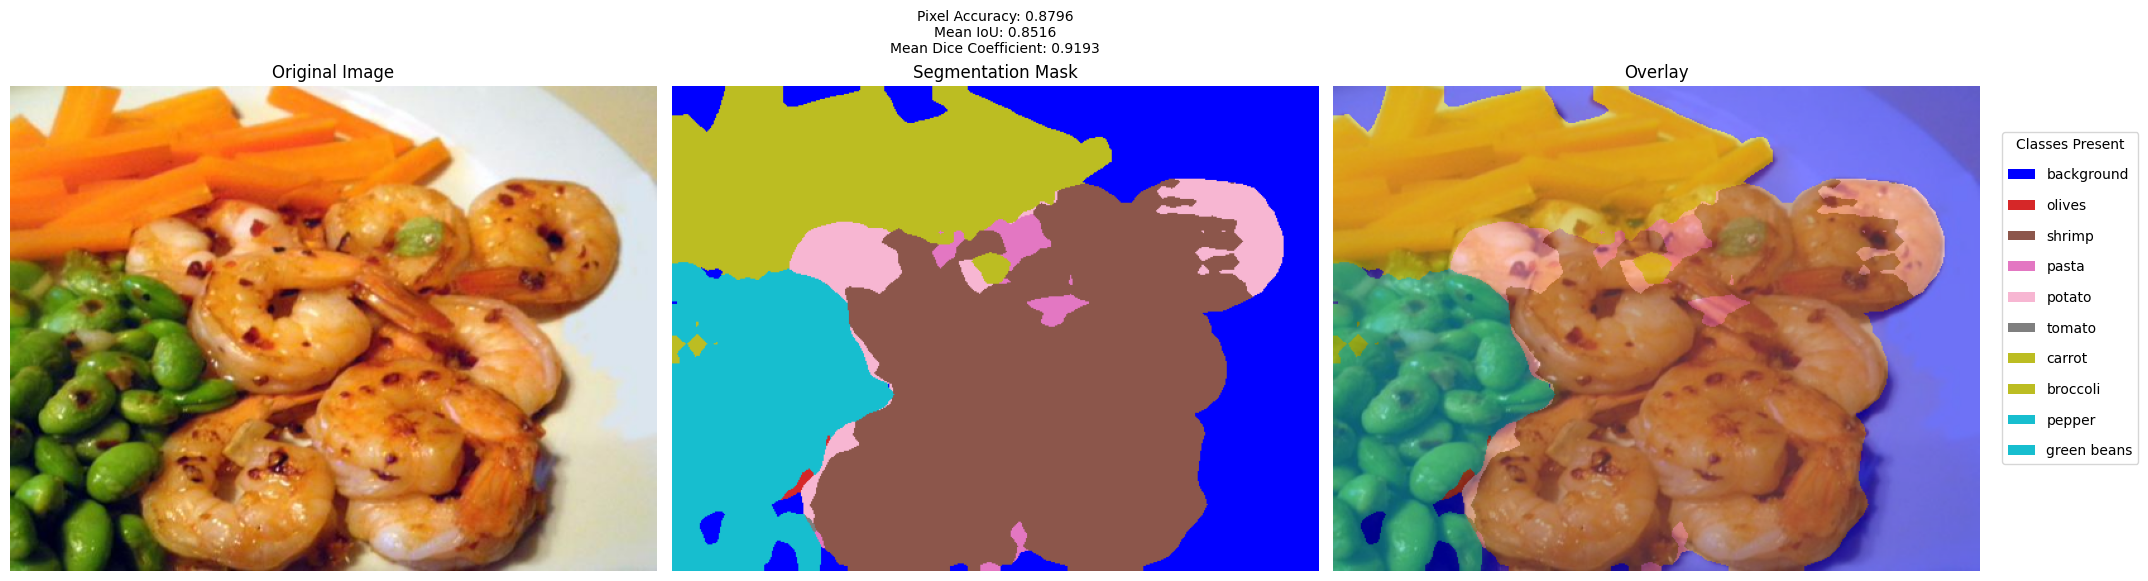

True classes in the image:
['background', 'shrimp', 'carrot', 'green beans']
Classes predicted:
['background', 'olives', 'shrimp', 'pasta', 'potato', 'tomato', 'carrot', 'broccoli', 'pepper', 'green beans']
Metrics:
Pixel Accuracy: 0.8796
Mean IoU: 0.8516
Mean Dice Coefficient: 0.9193


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = fcn_resnet50(num_classes=104)
checkpoint = torch.load('/kaggle/input/modelss/best_food_segmentation_model_test (2).pth',
                        map_location=device)
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model = model.to(device)

dataset = FoodSegDataset(root_dir='/kaggle/input/foodsegmentation', split='test')

# Load image and its ground truth
image_path = '/kaggle/input/foodsegmentation/test/img/00000263.jpg'

# Load ground truth mask
ground_truth_path = '/kaggle/input/foodsegmentation/test/ann/00000263.jpg.json'
with open(ground_truth_path, 'r') as f:
    annotation = json.load(f)

# Create ground truth mask similar to how it's done in the dataset class
ground_truth = np.zeros((annotation['size']['height'], annotation['size']['width']), dtype=np.int32)
for obj in annotation['objects']:
    original_class_id = obj['classId']
    mapped_class_id = dataset.class_mapping[original_class_id]
    bitmap_data = obj['bitmap']['data']
    origin = obj['bitmap']['origin']
    obj_mask = dataset.decode_bitmap(bitmap_data, origin, annotation['size'])
    ground_truth[obj_mask > 0] = mapped_class_id

# Resize ground truth to match target size
ground_truth_pil = Image.fromarray(ground_truth.astype(np.uint8))
ground_truth_resized = np.array(ground_truth_pil.resize(dataset.target_size[::-1], Image.Resampling.NEAREST))

class_names = get_class_names(dataset)
prediction, mask, overlay, metrics, legend_labels = predict_and_visualize(
    model=model,
    image_path=image_path,
    class_names=class_names,
    dataset=dataset,
    device=device,
    ground_truth=ground_truth_resized,
    save_path='segmentation_result_with_metrics.png'
)
true_classes = [
    class_names.get(cls, f'Unknown (class {cls})')
    for cls, iou in metrics['class_iou'].items()
    if iou > 0
]

print("True classes in the image:")
print(true_classes)
print("Classes predicted:")
print(legend_labels)
# Print out detailed metrics
print("Metrics:")
print(f"Pixel Accuracy: {metrics['pixel_accuracy']:.4f}")
print(f"Mean IoU: {metrics['mean_iou']:.4f}")
print(f"Mean Dice Coefficient: {metrics['mean_dice']:.4f}")